In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import os

# Assuming the CSV files are directly in the /content/ directory
actual_data_path = "/content/"

# Now read the CSV files from the actual data directory
customers = pd.read_csv(os.path.join(actual_data_path, "customers.csv"))
orders = pd.read_csv(os.path.join(actual_data_path, "orders.csv"))
deliveries = pd.read_csv(os.path.join(actual_data_path, "deliveries.csv"))
drivers = pd.read_csv(os.path.join(actual_data_path, "drivers.csv"))
vehicles = pd.read_csv(os.path.join(actual_data_path, "vehicles.csv"))
complaints = pd.read_csv(os.path.join(actual_data_path, "complaints.csv"))
incidents = pd.read_csv(os.path.join(actual_data_path, "incidents.csv"))
hubs = pd.read_csv(os.path.join(actual_data_path, "hubs.csv"))
app_events = pd.read_csv(os.path.join(actual_data_path, "app_events.csv"))

In [ ]:
#Preview Dataset
customers.head()

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


In [ ]:
orders.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
1,O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
2,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
3,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
4,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0


In [ ]:
#Check Missing Values
orders.isnull().sum()

,0
order_id,0
customer_id,0
service_type,0
order_created_at,0
promised_window_hours,0
pickup_zone,0
dropoff_zone,0
priority_level,0
order_value,0
booking_channel,25


In [ ]:
#Total Failed Deliveries
failed = deliveries[deliveries['delivery_status'] == 'Failed']

print("Total Failed Deliveries:", len(failed))

Total Failed Deliveries: 132


In [ ]:
#Complaint Severity Analysis
complaints['severity'].value_counts()

,count
severity,
Medium,172
High,77
Low,71


In [ ]:
#Average Driver Rating
drivers['driver_rating'].mean()

np.float64(4.171705882352941)

In [ ]:
#Top Pickup Zones
orders['pickup_zone'].value_counts().head(10)

,count
pickup_zone,
East,104
South,103
EAST,103
RiverSide,86
Airport,85
WEST,84
Ctr,80
CENTRAL,79
Central,79


In [ ]:
#Vehicle Maintenance Status
vehicles['maintenance_status'].value_counts()

,count
maintenance_status,
Active,67
InRepair,36
Scheduled,17


In [ ]:
#Merge Orders and Deliveries
merged_data = pd.merge(
    orders,
    deliveries,
    on='order_id'
)

merged_data.head()

,order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,...,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,...,V090,H01,2024-08-20 16:29:00,2024-08-20 18:52:56.172161,OnTime,26.65,2,0,4.29,15.82
1,O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,...,V100,H02,2025-09-02 16:59:00,2025-09-03 01:50:39.644673,Delayed,13.04,2,0,3.70,13.16
2,O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,...,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
3,O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,...,V073,H03,2025-02-17 20:23:00,2025-02-18 08:05:00.047082,OnTime,16.01,1,0,4.38,13.53
4,O00007,C0001,Business,2024-05-05 21:32:00,2,CENTRAL,Airport,Low,76.12,App,...,V047,H06,2024-05-05 22:10:00,2024-05-06 07:05:17.555250,Delayed,9.07,1,1,3.93,9.76


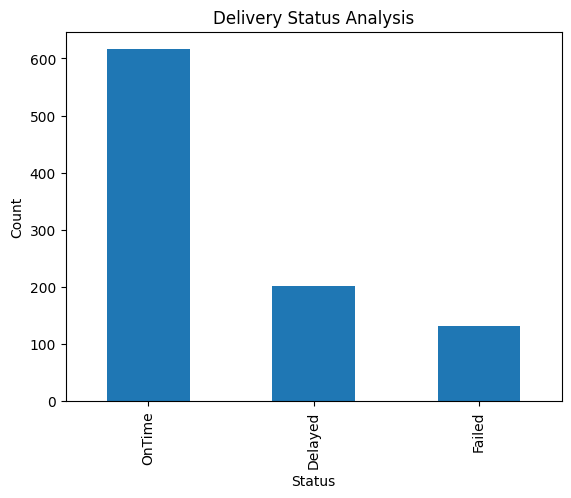

In [ ]:
#Delivery Status Chart
deliveries['delivery_status'].value_counts().plot(kind='bar')

plt.title("Delivery Status Analysis")
plt.xlabel("Status")
plt.ylabel("Count")

plt.show()

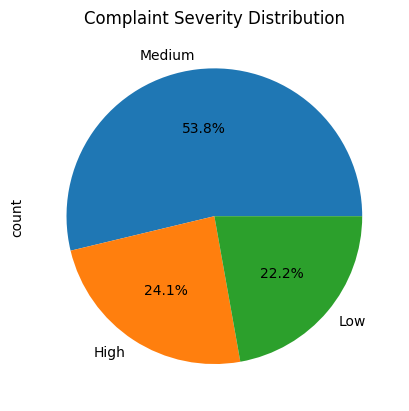

In [ ]:
#Complaint Severity Chart
complaints['severity'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Complaint Severity Distribution")

plt.show()

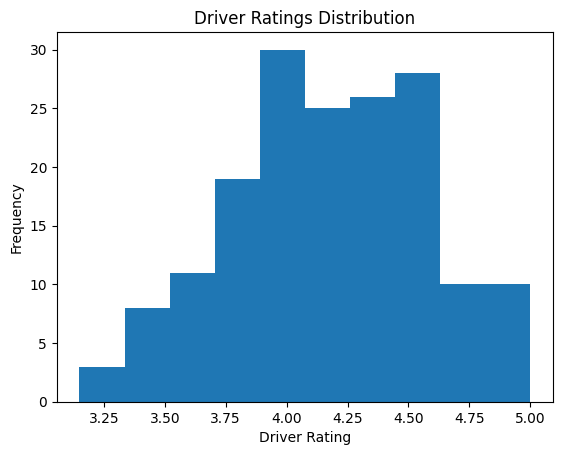

In [ ]:
#Driver Ratings Histogram
drivers['driver_rating'].plot(kind='hist')

plt.title("Driver Ratings Distribution")
plt.xlabel("Driver Rating")

plt.show()

In [ ]:
#App Latency Analysis
app_events['api_latency_ms'].describe()

,api_latency_ms
count,640.000000
mean,465.667188
std,271.634155
min,60.000000
25%,278.750000
50%,432.500000
75%,609.000000
max,1701.000000


In [ ]:
#Most Common Incident Types
incidents['incident_type'].value_counts().head(10)

,count
incident_type,
ProofMissing,46
CustomerNoShow,44
RouteDeviation,43
VehicleFault,37
BatteryAlert,36
AppSyncError,31
TemperatureIssue,29
SafetyNearMiss,14


**Save Cleaned Data (Optional Bonus)**

In [ ]:
#Save Cleaned Data (Optional Bonus)
merged_data = pd.merge(
    orders,
    deliveries,
    on='order_id'
)

merged_data.to_csv("merged_output.csv", index=False)

In [ ]:
import pandas as pd

merged_data = pd.merge(
    orders,
    deliveries,
    on='order_id'
)

merged_data.to_csv("merged_output.csv", index=False)

In [ ]:
# Load datasets
customers = pd.read_csv("customers.csv")
deliveries = pd.read_csv("deliveries.csv")
complaints = pd.read_csv("complaints.csv")

In [ ]:
# Preview customer dataset
customers.head()

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


In [ ]:
# Check missing values
customers.isnull().sum()

,0
customer_id,0
age,0
home_zone,0
customer_type,0
signup_date,0
loyalty_score,20
app_engagement_score,0
preferred_channel,13
account_status,0


In [ ]:
# Remove duplicate rows
customers.drop_duplicates(inplace=True)

In [ ]:
# Delivery status count
deliveries["delivery_status"].value_counts()

,count
delivery_status,
OnTime,616
Delayed,202
Failed,132


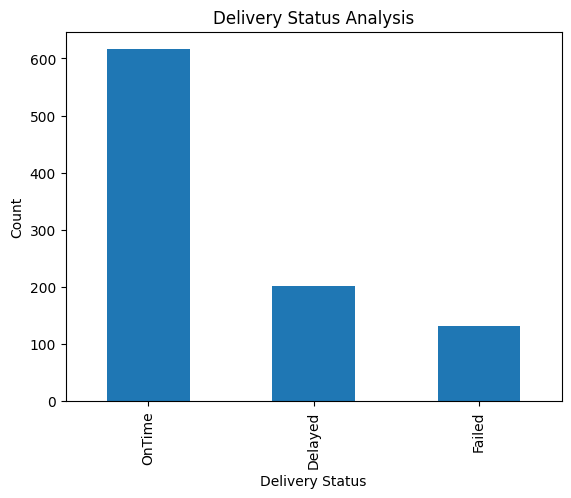

In [ ]:
# Delivery status bar chart
deliveries["delivery_status"].value_counts().plot(kind="bar")

plt.title("Delivery Status Analysis")
plt.xlabel("Delivery Status")
plt.ylabel("Count")

plt.show()

In [ ]:
# Complaint category analysis
complaints["complaint_type"].value_counts()

,count
complaint_type,
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


In [ ]:
# Operational zone analysis
# Convert relevant columns to datetime in deliveries
deliveries['dispatch_time'] = pd.to_datetime(deliveries['dispatch_time'])
deliveries['delivery_completed_at'] = pd.to_datetime(deliveries['delivery_completed_at'])

# Calculate delivery duration in minutes (as a proxy for delay_minutes)
deliveries['delivery_duration_minutes'] = (deliveries['delivery_completed_at'] - deliveries['dispatch_time']).dt.total_seconds() / 60

# Merge deliveries with hubs to get zone information
deliveries_with_zones = pd.merge(deliveries, hubs[['hub_id', 'zone']], on='hub_id', how='left')

# Group by zone and calculate the mean of delivery_duration_minutes
zone_analysis = deliveries_with_zones.groupby("zone")["delivery_duration_minutes"].mean()

print(zone_analysis)

zone
Airport      562.758006
Central      620.071935
East         459.414852
North        562.902086
Riverside    595.113258
South        532.024348
West         619.829453
Name: delivery_duration_minutes, dtype: float64


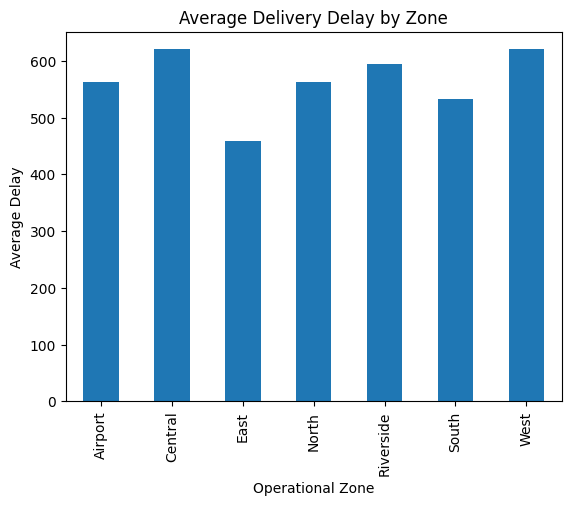

In [ ]:
# Zone analysis chart
zone_analysis.plot(kind="bar")

plt.title("Average Delivery Delay by Zone")
plt.xlabel("Operational Zone")
plt.ylabel("Average Delay")

plt.show()